In [1]:
import matplotlib as mpl
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import glob

In [2]:
1/0.33407

2.993384619989823

In [3]:
# known_tois = pd.read_csv('../data/toi-catalog.csv', skiprows =2)
known_tois = pd.read_csv('../data/PS_2026.02.17_18.13.58.csv', skiprows =110)

known_tois


,pl_name,hostname,tic_id,gaia_dr3_id,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,...,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,sy_tmag,sy_tmagerr1,sy_tmagerr2,rowupdate,pl_pubdate,releasedate
0,LP 890-9 b,LP 890-9,TIC 44898913,Gaia DR3 4886243456388510720,1,1,2,Transit,2022,Transiting Exoplanet Survey Satellite (TESS),...,-0.023,15.82130,0.000763,-0.000763,14.2683,0.007557,-0.007557,2022-09-14,2022-09,2022-09-14
1,LP 791-18 b,LP 791-18,TIC 181804752,Gaia DR3 3562427951852172288,1,1,3,Transit,2019,Transiting Exoplanet Survey Satellite (TESS),...,-0.023,15.07150,0.001324,-0.001324,13.5571,0.007732,-0.007732,2023-05-14,2023-05,2023-05-14
2,LP 791-18 c,LP 791-18,TIC 181804752,Gaia DR3 3562427951852172288,1,1,3,Transit,2019,Transiting Exoplanet Survey Satellite (TESS),...,-0.023,15.07150,0.001324,-0.001324,13.5571,0.007732,-0.007732,2023-05-14,2023-05,2023-05-14
3,LHS 3844 b,LHS 3844,TIC 410153553,Gaia DR3 6385548541499112448,1,1,1,Transit,2019,Transiting Exoplanet Survey Satellite (TESS),...,-0.023,13.39250,0.000738,-0.000738,11.9238,0.007698,-0.007698,2019-01-22,2019-02,2019-01-24
4,TOI-540 b,TOI-540,TIC 200322593,Gaia DR3 4785886941312921344,1,1,1,Transit,2020,Transiting Exoplanet Survey Satellite (TESS),...,-0.021,12.89380,0.000481,-0.000481,11.5045,0.007318,-0.007318,2020-10-01,2021-01,2020-10-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,TOI-2427 b,TOI-2427,TIC 142937186,Gaia DR3 5055663973297050624,1,1,1,Transit,2022,Transiting Exoplanet Survey Satellite (TESS),...,-0.024,9.81845,0.000540,-0.000540,9.0138,0.006000,-0.006000,2022-02-15,2022-02,2022-02-15
187,TOI-3757 b,TOI-3757,TIC 445751830,Gaia DR3 996878131494639488,1,1,1,Transit,2022,Transiting Exoplanet Survey Satellite (TESS),...,-0.020,14.13210,0.000442,-0.000442,13.1858,0.007332,-0.007332,2022-08-22,2022-09,2022-08-22
188,TOI-6303 b,TOI-6303,TIC 186810676,Gaia DR3 239050153051494272,1,1,1,Transit,2025,Transiting Exoplanet Survey Satellite (TESS),...,-0.016,13.91140,0.000482,-0.000482,12.9386,0.007343,-0.007343,2025-09-17,2025-07,2025-09-17
189,TOI-2379 b,TOI-2379,TIC 201177276,Gaia DR3 6521531466699512064,1,1,1,Transit,2024,Transiting Exoplanet Survey Satellite (TESS),...,-0.023,14.66010,0.000323,-0.000323,13.6521,0.007308,-0.007308,2024-09-17,2024-10,2024-09-17


In [4]:
tic_ids = ['TIC '+(file.split('/')[2].split('-')[1].split('_')[0]) for file in glob.glob('../new_toi_data/*check')]

In [5]:
tic_ids

['TIC 388076422',
 'TIC 284441182',
 'TIC 233602827',
 'TIC 308120029',
 'TIC 172370679',
 'TIC 445751830',
 'TIC 285048486',
 'TIC 46432937',
 'TIC 413248763',
 'TIC 103633434',
 'TIC 271169413',
 'TIC 193634953',
 'TIC 27649847',
 'TIC 52005579',
 'TIC 212957629',
 'TIC 55650590',
 'TIC 158588995',
 'TIC 163539739',
 'TIC 384888319',
 'TIC 8348911',
 'TIC 26054627',
 'TIC 28900646',
 'TIC 4918918',
 'TIC 4070275',
 'TIC 420112589',
 'TIC 377293776',
 'TIC 389900760',
 'TIC 321669174',
 'TIC 410153553',
 'TIC 387690507',
 'TIC 447061717',
 'TIC 67512645',
 'TIC 422756130',
 'TIC 44898913',
 'TIC 468983280',
 'TIC 77156829',
 'TIC 396562848',
 'TIC 307210830',
 'TIC 467179528',
 'TIC 271971130',
 'TIC 86263325',
 'TIC 95057860',
 'TIC 16005254',
 'TIC 98796344',
 'TIC 260004324',
 'TIC 260708537',
 'TIC 441738827',
 'TIC 186810676',
 'TIC 155867025',
 'TIC 144700903',
 'TIC 250111245',
 'TIC 201186294',
 'TIC 165202476',
 'TIC 181804752',
 'TIC 166184428',
 'TIC 119584412',
 'TIC 11832

In [6]:
failed_2 = ['TIC '+(file.split('/')[-1].split('-')[1].split('_')[0]) for file in glob.glob('../new_toi_data/*data')]




failed_1 = ['TIC '+(file.split('/')[-1].split('-')[1].split('_')[0]) for file in glob.glob('../new_toi_data/t*') if 'data' not in file.split('/')[-1]]



In [7]:
failed_2

['TIC 142937186',
 'TIC 119585136',
 'TIC 116483514',
 'TIC 470381900',
 'TIC 230055368',
 'TIC 357501308',
 'TIC 382602147',
 'TIC 417931300',
 'TIC 439867639',
 'TIC 50618703']

In [8]:
known_tois.columns

Index(['pl_name', 'hostname', 'tic_id', 'gaia_dr3_id', 'default_flag',
       'sy_snum', 'sy_pnum', 'discoverymethod', 'disc_year', 'disc_facility',
       'soltype', 'pl_controv_flag', 'pl_refname', 'pl_orbper',
       'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax',
       'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade',
       'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1',
       'pl_radjerr2', 'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1',
       'pl_bmasseerr2', 'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1',
       'pl_bmassjerr2', 'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen',
       'pl_orbeccenerr1', 'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol',
       'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1',
       'pl_eqterr2', 'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype',
       'st_teff', 'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad',
       'st_raderr1', 'st_raderr2', 'st_radlim', 'st_mass', 's

In [9]:
known_tois['transit_depth'] = (known_tois.pl_rade/known_tois.st_rad/109.076)**2

In [10]:
searched_tois = known_tois[known_tois['default_flag']==1].reset_index(drop=True)[['tic_id', 'pl_orbper', 'transit_depth', 'sy_pnum', 'pl_rade']]

# searched_tois.TIC = 'TIC '+str(searched_tois.TIC)


In [11]:
# known_tois.pl_rade/known_tois.st_rad/109.076

In [12]:
# searched_tois = searched_tois[searched_tois['Orbital Period (days) Value']<1E3]

In [13]:
# set(searched_tois['TOI Disposition'])

In [14]:
# searched_tois['Transit Depth Value'] = searched_tois['Transit Depth Value']/1E6
searched_tois

,tic_id,pl_orbper,transit_depth,sy_pnum,pl_rade
0,TIC 44898913,2.729903,0.006049,2,1.320000
1,TIC 181804752,0.947998,0.003727,3,1.212000
2,TIC 181804752,4.989909,0.015082,3,2.438000
3,TIC 410153553,0.462929,0.003995,1,1.303000
4,TIC 200322593,1.239149,0.001909,1,0.903000
...,...,...,...,...,...
186,TIC 142937186,1.306001,0.000645,1,1.800000
187,TIC 445751830,3.438753,0.031486,1,12.000000
188,TIC 186810676,9.485236,0.030442,1,11.590000
189,TIC 201177276,5.469383,0.029865,1,11.724594


In [15]:
len(set(searched_tois.tic_id))

161

In [56]:
convergence_test_files_singles = glob.glob('../checking_convergence_output/confidence_0.6/*single*final.csv')



convergence_test_files_periodic = glob.glob('../checking_convergence_output/confidence_0.6/*per*final.csv')


len(convergence_test_files_singles), len(convergence_test_files_periodic)

(0, 0)

In [17]:
convergence_test_files_singles = glob.glob('../checking_convergence_output/confidence_0.55/*single*.csv')



convergence_test_files_periodic = glob.glob('../checking_convergence_output/confidence_0.55/*per*.csv')


len(convergence_test_files_singles), len(convergence_test_files_periodic)

(0, 0)

In [57]:
convergence_test_files_singles = glob.glob('../checking_convergence_output/*single*final.csv')



convergence_test_files_periodic = glob.glob('../checking_convergence_output/*per*final.csv')


len(convergence_test_files_singles), len(convergence_test_files_periodic)

(113, 292)

In [58]:
# convergence_test_files_singles = glob.glob('../checking_convergence_output/*single*.csv')



# convergence_test_files_periodic = glob.glob('../checking_convergence_output/*per*.csv')


# len(convergence_test_files_singles), len(convergence_test_files_periodic)

In [59]:

converg_tests_singles = pd.concat((pd.read_csv(f, index_col = 0) for f in convergence_test_files_singles), ignore_index=True)
converg_tests_singles.TICID = ['TIC '+str(converg_tests_singles.TICID[x] ) for x in range(len(converg_tests_singles))]

In [60]:
converg_tests_periodic = pd.concat((pd.read_csv(f, index_col = 0) for f in convergence_test_files_periodic), ignore_index=True)
converg_tests_periodic.TICID = ['TIC '+str(converg_tests_periodic.TICID[x] ) for x in range(len(converg_tests_periodic))]

In [61]:
converg_tests_periodic

,TICID,t0,per,depth,converged,conv_on_run
0,TIC 155867025,1816.806,2.155,0.044,True,2.0
1,TIC 144700903,1470.581,2.324,0.009,True,2.0
2,TIC 165202476,2145.199,2.909,0.046,True,3.0
3,TIC 181804752,1546.499,4.993,0.015,True,3.0
4,TIC 163539739,1711.898,1.828,0.000,True,2.0
...,...,...,...,...,...,...
287,TIC 260004324,1329.960,1.640,0.000,True,2.0
288,TIC 260708537,1336.634,2.102,0.000,True,2.0
289,TIC 260708537,1371.006,2.078,0.000,True,2.0
290,TIC 260004324,1330.378,0.861,0.000,True,2.0


In [90]:
real_val_conv_test_singles = converg_tests_singles.copy()

real_val_conv_test_singles['int_multi'] = np.nan
real_val_conv_test_singles['correct'] = False
real_val_conv_test_singles['alias'] = False
real_val_conv_test_singles['true_per'] = np.nan

for indx, row in real_val_conv_test_singles.iterrows():
    ticid = row.TICID
    toi = searched_tois[searched_tois['tic_id']==ticid].reset_index(drop=True)
    
    t0_found  = row.t0
    per_found = row.per
    
    for toi_indx, toi_row in toi.iterrows():
#         t0_known = toi_row['Orbital Epoch Value']
        per_known = toi_row['pl_orbper']

#         num_epochs = abs(t0_found-t0_known)/per_known

#         check_int = (abs(num_epochs - np.round(num_epochs, 1)) < 1E-2) or (abs(1/num_epochs - np.round(1/num_epochs, 1)) < 1E-2)

# #         print(abs(num_epochs - np.round(num_epochs, 1)), abs(1/num_epochs - np.round(1/num_epochs, 1)))
# #         print(check_int)
#         if check_int:
#             real_val_conv_test_singles.loc[indx,'t0'] = t0_known
        
        
        per_int = per_known/per_found
        
        per_int_big = max([per_int, 1/per_int])
        
        check_per = (abs(per_int_big - np.round(per_int_big,4)) < 1E-3) or abs((per_known - per_found)<1E-4)

        if check_per and (np.round(per_int_big)== 1):
            real_val_conv_test_singles.loc[indx,'correct'] = True
            real_val_conv_test_singles.loc[indx,'alias'] = True
            real_val_conv_test_singles.loc[indx,'int_multi'] = 1
            real_val_conv_test_singles.loc[indx,'true_per'] = per_known
        elif check_per and (np.round(per_int_big)!= 1):
            real_val_conv_test_singles.loc[indx,'correct'] = False
            real_val_conv_test_singles.loc[indx,'alias'] = True
            real_val_conv_test_singles.loc[indx,'int_multi'] = round(per_int)
            real_val_conv_test_singles.loc[indx,'true_per'] = per_known
        

In [91]:
real_val_conv_test_periodic = converg_tests_periodic.copy()

real_val_conv_test_periodic['int_multi'] = np.nan
real_val_conv_test_periodic['correct'] = False
real_val_conv_test_periodic['alias'] = False
real_val_conv_test_periodic['true_per'] = np.nan

for indx, row in real_val_conv_test_periodic.iterrows():
    ticid = row.TICID
    toi = searched_tois[searched_tois['tic_id']==ticid].reset_index(drop=True)
    
    t0_found  = row.t0
    per_found = row.per
    
    for toi_indx, toi_row in toi.iterrows():
#         t0_known = toi_row['Orbital Epoch Value']
        per_known = toi_row['pl_orbper']

#         num_epochs = abs(t0_found-t0_known)/per_known

#         check_int = (abs(num_epochs - np.round(num_epochs, 1)) < 1E-2) or (abs(1/num_epochs - np.round(1/num_epochs, 1)) < 1E-2)

# #         print(abs(num_epochs - np.round(num_epochs, 1)), abs(1/num_epochs - np.round(1/num_epochs, 1)))
# #         print(check_int)
#         if check_int:
#             real_val_conv_test_periodic.loc[indx,'t0'] = t0_known
        
        
        per_int = per_known/per_found
        
        per_int_big = max([per_int, 1/per_int])
        
        check_per = (abs(per_int_big - np.round(per_int_big,4)) < 1E-3) or abs((per_known - per_found)<1E-4)

        if check_per and (np.round(per_int)== 1):
            real_val_conv_test_periodic.loc[indx,'correct'] = True
            real_val_conv_test_periodic.loc[indx,'alias'] = True
            real_val_conv_test_periodic.loc[indx,'int_multi'] = 1
            real_val_conv_test_periodic.loc[indx,'true_per'] = per_known
        elif check_per and (np.round(per_int)!= 1):
            real_val_conv_test_periodic.loc[indx,'correct'] = False
            real_val_conv_test_periodic.loc[indx,'alias'] = True
            real_val_conv_test_periodic.loc[indx,'int_multi'] = round(per_int)
            real_val_conv_test_periodic.loc[indx,'true_per'] = per_known
        

In [92]:
real_val_conv_test_singles[real_val_conv_test_singles['TICID'] == 'TIC 445751830']

,TICID,t0,per,depth,converged,conv_on_run,int_multi,correct,alias,true_per


array([[<Axes: title={'center': 'conv_on_run'}>]], dtype=object)

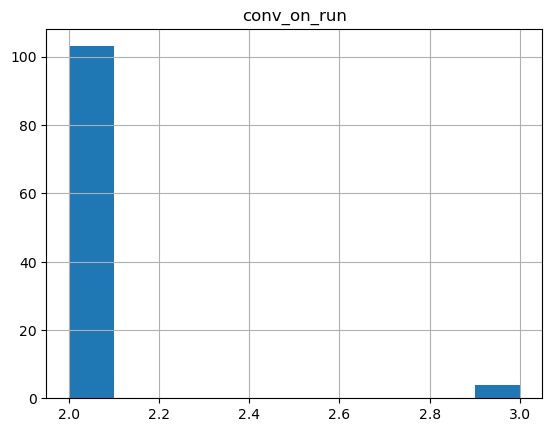

In [93]:
real_val_conv_test_singles.hist('conv_on_run')

array([[<Axes: title={'center': 'conv_on_run'}>]], dtype=object)

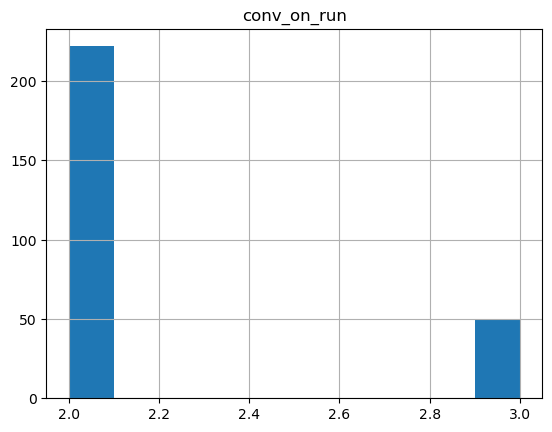

In [94]:
real_val_conv_test_periodic.hist('conv_on_run')

In [95]:
real_val_conv_test_periodic = converg_tests_periodic.copy()

real_val_conv_test_periodic['int_multi'] = np.nan
real_val_conv_test_periodic['correct'] = False
real_val_conv_test_periodic['alias'] = False
real_val_conv_test_periodic['true_per'] = np.nan

for indx, row in real_val_conv_test_periodic.iterrows():
    ticid = row.TICID
    toi = searched_tois[searched_tois['tic_id']==ticid].reset_index(drop=True)
    
    t0_found  = row.t0
    per_found = row.per
    
    for toi_indx, toi_row in toi.iterrows():
#         t0_known = toi_row['Orbital Epoch Value']
        per_known = toi_row['pl_orbper']

#         num_epochs = abs(t0_found-t0_known)/per_known

#         check_int = (abs(num_epochs - np.round(num_epochs, 1)) < 1E-2) or (abs(1/num_epochs - np.round(1/num_epochs, 1)) < 1E-2)

# #         print(abs(num_epochs - np.round(num_epochs, 1)), abs(1/num_epochs - np.round(1/num_epochs, 1)))
# #         print(check_int)
#         if check_int:
#             real_val_conv_test_periodic.loc[indx,'t0'] = t0_known
        
        
        per_int = per_known/per_found
        
        per_int_big = max([per_int, 1/per_int])
        
        check_per = (abs(per_int_big - np.round(per_int_big,4)) < 1E-3) or abs((per_known - per_found)<1E-4)
        print(check_per)

        if check_per and (np.round(per_int)== 1):
            real_val_conv_test_periodic.loc[indx,'correct'] = True
            real_val_conv_test_periodic.loc[indx,'alias'] = True
            real_val_conv_test_periodic.loc[indx,'int_multi'] = 1
            real_val_conv_test_periodic.loc[indx,'true_per'] = per_known
        elif check_per and (np.round(per_int)!= 1):
            real_val_conv_test_periodic.loc[indx,'correct'] = False
            real_val_conv_test_periodic.loc[indx,'alias'] = True
            real_val_conv_test_periodic.loc[indx,'int_multi'] = round(per_int)
            
            real_val_conv_test_periodic.loc[indx,'true_per'] = per_known

        

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [96]:

7.727000/2.582000

2.992641363284276

In [97]:
# axs.plot(real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['multiple'] == True) & (real_val_conv_test_singles['correct'] == False)].true_per, 
#          real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['multiple'] == True) & (real_val_conv_test_singles['correct'] == False)].TICID.astype(str), 
#          marker='s', markersize=10,  markerfacecolor='none', markeredgecolor='cyan', linestyle='None', markeredgewidth = 1.5, zorder = -1,  alpha = 0.8)


In [98]:
real_val_conv_test_singles

,TICID,t0,per,depth,converged,conv_on_run,int_multi,correct,alias,true_per
0,TIC 112115898,2235.803,761.934,0.000,True,2.0,0.0,False,True,4.718590
1,TIC 102734241,2792.745,1140.878,0.005,True,2.0,0.0,False,True,10.904821
2,TIC 186810676,1810.209,6.332,0.040,True,3.0,1.0,True,True,9.485236
3,TIC 155867025,1823.280,19.534,0.020,True,2.0,0.0,False,True,2.154849
4,TIC 102734241,2779.724,1140.995,0.001,True,2.0,0.0,False,True,10.904821
...,...,...,...,...,...,...,...,...,...,...
108,TIC 260708537,2102.564,1063.267,0.000,True,2.0,0.0,False,True,1.744700
109,TIC 260708537,1343.625,1064.510,0.000,True,2.0,0.0,False,True,1.744700
110,TIC 359271092,1546.805,786.536,0.000,True,2.0,0.0,False,True,7.576860
111,TIC 260708537,2374.343,1062.088,0.001,True,2.0,0.0,False,True,1.744700


In [99]:
a = (real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['correct'] == True)
b = (real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['alias'] == True) & (real_val_conv_test_singles['correct'] == False)
c = (real_val_conv_test_singles['converged'] == False) & (real_val_conv_test_singles['correct'] == True)


real_val_conv_test_singles[a | b  | c]

ok_ticids_singles = list(set(real_val_conv_test_singles[a | b  | c].TICID))


multi_tic_singles = list(set(real_val_conv_test_singles[b].TICID))\


correct_tic_singles = list(set(real_val_conv_test_singles[a].TICID))



In [100]:
d = (real_val_conv_test_periodic['converged'] == True) & (real_val_conv_test_periodic['correct'] == True)
e = (real_val_conv_test_periodic['converged'] == True) & (real_val_conv_test_periodic['alias'] == True) & (real_val_conv_test_periodic['correct'] == False)
f = (real_val_conv_test_periodic['converged'] == False) & (real_val_conv_test_periodic['correct'] == True)

ok_ticids_periodic = list(set(real_val_conv_test_periodic[d | e  | f].TICID))


multi_tic_periodic = list(set(real_val_conv_test_periodic[e].TICID))

correct_tic_periodic = list(set(real_val_conv_test_periodic[d ].TICID))





In [101]:
correct_ticids = list(set(correct_tic_periodic+correct_tic_singles
                         ))

In [102]:
multi_ticids = set(multi_tic_periodic+multi_tic_singles)

In [103]:
len(set(searched_tois.tic_id))

161

In [104]:
searched_tois = searched_tois.sort_values('pl_rade', ascending=False)

In [105]:
(0.102763)**2**2

0.00011151854570411509

In [106]:
big = list(searched_tois[searched_tois['transit_depth']>0.005].tic_id)

In [107]:
# searched_tois = searched_tois[searched_tois['tic_id'].isin(big)]

In [108]:
print(list(set(searched_tois.sort_values('sy_pnum', ascending=False).tic_id)))

['TIC 370133522', 'TIC 277634430', 'TIC 384888319', 'TIC 452866790', 'TIC 459323923', 'TIC 119585136', 'TIC 285048486', 'TIC 116483514', 'TIC 307809773', 'TIC 455784423', 'TIC 271169413', 'TIC 369327947', 'TIC 219698776', 'TIC 95057860', 'TIC 86263325', 'TIC 261135533', 'TIC 445751830', 'TIC 240968774', 'TIC 296739893', 'TIC 103633434', 'TIC 377293776', 'TIC 308120029', 'TIC 150428135', 'TIC 70899085', 'TIC 165202476', 'TIC 260004324', 'TIC 163539739', 'TIC 198385543', 'TIC 310380289', 'TIC 354944123', 'TIC 28900646', 'TIC 178709444', 'TIC 332657786', 'TIC 458419328', 'TIC 212957629', 'TIC 22233480', 'TIC 201186294', 'TIC 447061717', 'TIC 413248763', 'TIC 286201103', 'TIC 144700903', 'TIC 417931300', 'TIC 201177276', 'TIC 193336820', 'TIC 260708537', 'TIC 389900760', 'TIC 158588995', 'TIC 351601843', 'TIC 77156829', 'TIC 218795833', 'TIC 153951307', 'TIC 368287008', 'TIC 439456714', 'TIC 112115898', 'TIC 243185500', 'TIC 234994474', 'TIC 406941612', 'TIC 142937186', 'TIC 16005254', 'TI

In [109]:
len(glob.glob('../new_toi_data/t*'))#-len(failed_2)

158

In [110]:
failed_2

['TIC 142937186',
 'TIC 119585136',
 'TIC 116483514',
 'TIC 470381900',
 'TIC 230055368',
 'TIC 357501308',
 'TIC 382602147',
 'TIC 417931300',
 'TIC 439867639',
 'TIC 50618703']

In [111]:


a = (real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['correct'] == True)
b = (real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['alias'] == True) & (real_val_conv_test_singles['correct'] == False)
c = (real_val_conv_test_singles['converged'] == False) & (real_val_conv_test_singles['correct'] == True)


real_val_conv_test_singles[a | b  | c]

ok_ticids_singles = list(set(real_val_conv_test_singles[a | b  | c].TICID))


multi_tic_singles = list(set(real_val_conv_test_singles[b].TICID))\


correct_tic_singles = list(set(real_val_conv_test_singles[a].TICID))




d = (real_val_conv_test_periodic['converged'] == True) & (real_val_conv_test_periodic['correct'] == True)
e = (real_val_conv_test_periodic['converged'] == True) & (real_val_conv_test_periodic['alias'] == True) & (real_val_conv_test_periodic['correct'] == False)
f = (real_val_conv_test_periodic['converged'] == False) & (real_val_conv_test_periodic['correct'] == True)

ok_ticids_periodic = list(set(real_val_conv_test_periodic[d | e  | f].TICID))


multi_tic_periodic = list(set(real_val_conv_test_periodic[e].TICID))

correct_tic_periodic = list(set(real_val_conv_test_periodic[d ].TICID))





In [112]:
searched_tois = searched_tois.reset_index(drop=True)
searched_tois

,tic_id,pl_orbper,transit_depth,sy_pnum,pl_rade
0,TIC 95057860,3.581919,0.039602,1,13.674956
1,TIC 46432937,1.440445,0.053079,1,13.316269
2,TIC 459323923,2.652062,0.118871,1,13.200000
3,TIC 165202476,2.908917,0.037378,1,12.441969
4,TIC 163539739,14.475670,0.038214,1,12.217789
...,...,...,...,...,...
186,TIC 307210830,2.253114,0.000592,5,0.837000
187,TIC 34068865,0.321923,0.000196,3,0.699000
188,TIC 77156829,0.860232,0.000364,3,0.685000
189,TIC 260708537,1.744700,0.000145,1,0.566000


In [113]:
len(set(searched_tois['tic_id']))

161

In [114]:
ticids   = []
mx_radii = []
indxs_unsort = []
for indx, row in searched_tois.iterrows():
    tic   = row['tic_id']
    if tic in ticids:
        continue
    small = searched_tois[searched_tois['tic_id'] == tic]
#     print(small, np.nanmax(small['pl_rade']))
    mx_radii.append(np.nanmax(small['pl_rade']))
    ticids.append(tic)
    indxs_unsort.append(indx)

ticids_set = np.array(ticids)[np.argsort(mx_radii)]

# sort_indxs = np.array(indxs_unsort)[np.argsort(radii)]
# radii = np.array(radii)#.astype(str)
indxs_unsort

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 78,
 79,
 80,
 83,
 84,
 85,
 87,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 97,
 99,
 100,
 102,
 103,
 104,
 105,
 106,
 107,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 135,
 137,
 138,
 139,
 142,
 144,
 145,
 146,
 149,
 150,
 152,
 154,
 156,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 181,
 183,
 184,
 185,
 187,
 189]

In [115]:
print(list(searched_tois[searched_tois.pl_rade>5].tic_id))

['TIC 95057860', 'TIC 46432937', 'TIC 459323923', 'TIC 165202476', 'TIC 163539739', 'TIC 445751830', 'TIC 388076422', 'TIC 250111245', 'TIC 201177276', 'TIC 419411415', 'TIC 186810676', 'TIC 218795833', 'TIC 382602147', 'TIC 243641947', 'TIC 155867025', 'TIC 328513434', 'TIC 172370679', 'TIC 308120029', 'TIC 16005254', 'TIC 119585136', 'TIC 193634953', 'TIC 26054627', 'TIC 459762279', 'TIC 67512645', 'TIC 360156606', 'TIC 387690507', 'TIC 335590096', 'TIC 178709444', 'TIC 455784423', 'TIC 20182780', 'TIC 86263325', 'TIC 144700903', 'TIC 348755728', 'TIC 151825527', 'TIC 158588995', 'TIC 458419328', 'TIC 288144647', 'TIC 285048486']


In [116]:
final_found_planets = pd.read_csv('../data/saving_all_planets.csv')
final_found_planets

,TICID,Planet_Num,Ptype,T0,Period,Depth,Dur,Rad_p,Cosi,Semi_Maj,b,u1,u2,Norm,Win,Tau,SNR
0,112115898,1.0,Single,2235.803,761.934,0.000,0.271,0.007,0.000,899.682,0.008,0.1533,0.4776,1.000,0.543,0.002,2.513
1,144700903,1.0,Period,1470.581,2.324,0.009,0.067,0.095,0.001,20.139,0.009,0.2581,0.3609,1.000,0.135,0.006,929.529
2,186810676,1.0,Single,1810.209,6.332,0.040,0.124,0.199,0.000,19.404,0.008,0.2581,0.3609,0.999,0.247,0.020,470.003
3,155867025,2.0,Single,1823.280,19.534,0.020,0.148,0.140,0.000,47.679,0.008,0.1959,0.4178,1.000,0.295,0.018,325.849
4,102734241,2.0,Single,2779.724,1140.995,0.001,0.330,0.030,0.000,1132.178,0.008,0.1529,0.4604,0.999,0.661,0.010,7.717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,235678745,19.0,Period,1786.119,2.306,0.000,0.013,0.008,0.000,125.549,0.008,0.1737,0.4118,1.000,0.025,0.000,448.565
108,233602827,21.0,Period,1705.780,18.467,0.001,0.051,0.024,0.000,153.102,0.008,0.3390,0.2994,1.000,0.103,0.001,1018.142
109,359271092,8.0,Single,1546.805,786.536,0.000,0.461,0.012,0.000,549.741,0.008,0.2315,0.3808,1.000,0.922,0.005,14.801
110,260708537,36.0,Period,1371.006,2.078,0.000,0.057,0.003,0.001,12.802,0.008,0.1604,0.4325,1.000,0.115,0.000,20.576


Using matplotlib backend: module://matplotlib_inline.backend_inline


(-10.0, 100.0)

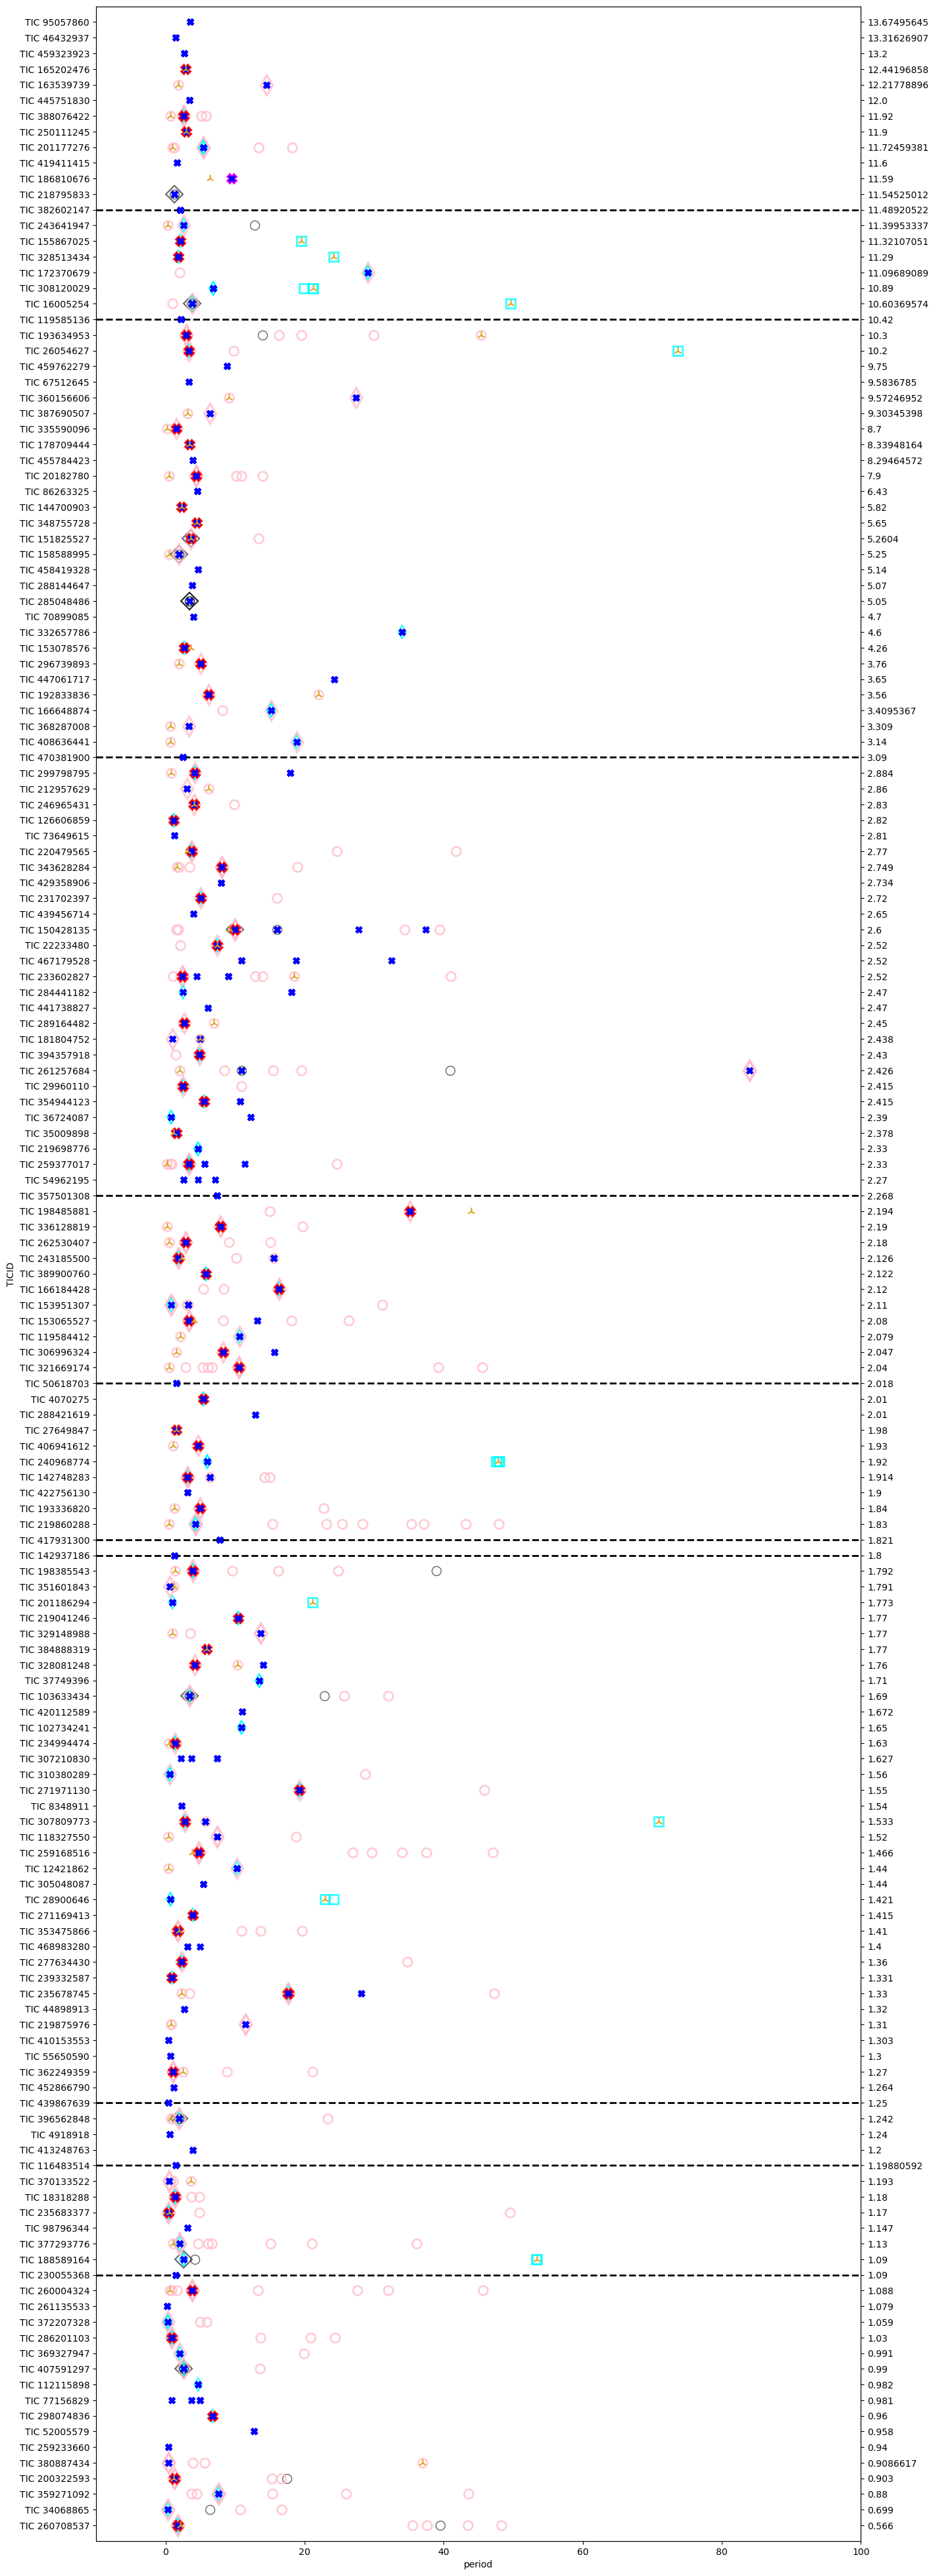

In [117]:

%matplotlib 

fig, axs = plt.subplots(1, figsize=(15, 50))


yticks = np.arange(161)



axs.scatter(searched_tois['pl_orbper'][indxs_unsort[::-1]], searched_tois['tic_id'].astype(str)[indxs_unsort[::-1]], color = 'b', marker = 'X', s = 50, zorder = 1E3)

axs.plot(real_val_conv_test_periodic[(real_val_conv_test_periodic['converged'] == True) & (real_val_conv_test_periodic['correct'] == True)].true_per, 
         real_val_conv_test_periodic[(real_val_conv_test_periodic['converged'] == True) & (real_val_conv_test_periodic['correct'] == True)].TICID.astype(str), 
         marker='X', markersize=10,  markerfacecolor='none', markeredgecolor='red', linestyle='None', markeredgewidth = 2, zorder = 2000, alpha = 1)


axs.plot(real_val_conv_test_periodic[(real_val_conv_test_periodic['converged'] == True) & (real_val_conv_test_periodic['alias'] == True) & (real_val_conv_test_periodic['correct'] == False)].true_per, 
         real_val_conv_test_periodic[(real_val_conv_test_periodic['converged'] == True) & (real_val_conv_test_periodic['alias'] == True) & (real_val_conv_test_periodic['correct'] == False)].TICID.astype(str), 
         marker='d', markersize=15,  markerfacecolor='none', markeredgecolor='pink', linestyle='None', markeredgewidth = 2.5, zorder = 0,  alpha = 0.8)


axs.plot(real_val_conv_test_periodic[(real_val_conv_test_periodic['converged'] == True) & (real_val_conv_test_periodic['alias'] == True) & (real_val_conv_test_periodic['correct'] == False)].per, 
         real_val_conv_test_periodic[(real_val_conv_test_periodic['converged'] == True) & (real_val_conv_test_periodic['alias'] == True) & (real_val_conv_test_periodic['correct'] == False)].TICID.astype(str), 
         marker='o', markersize=10,  markerfacecolor='none', markeredgecolor='pink', linestyle='None', markeredgewidth = 2, zorder = 200,  alpha = 0.8)


axs.plot(real_val_conv_test_periodic[(real_val_conv_test_periodic['converged'] == True)  & (real_val_conv_test_periodic['alias'] == False)].per, 
         real_val_conv_test_periodic[(real_val_conv_test_periodic['converged'] == True)  & (real_val_conv_test_periodic['alias'] == False)].TICID.astype(str), 
         marker='o', markersize=10,  markerfacecolor='none', markeredgecolor='orange', linestyle='None', markeredgewidth = 2, zorder = 75,  alpha = 0.5)

axs.plot(real_val_conv_test_periodic[real_val_conv_test_periodic['converged'] == False].per, 
         real_val_conv_test_periodic[real_val_conv_test_periodic['converged'] == False].TICID.astype(str), 
         marker='o', markersize=10,  markerfacecolor='none', markeredgecolor='black', linestyle='None', markeredgewidth = 1, zorder = 20,  alpha = 0.6)

axs.plot(real_val_conv_test_periodic[(real_val_conv_test_periodic['converged'] == False) & (real_val_conv_test_periodic['correct'] == True)].true_per, 
         real_val_conv_test_periodic[(real_val_conv_test_periodic['converged'] == False) & (real_val_conv_test_periodic['correct'] == True)].TICID.astype(str), 
         marker='D', markersize=13,  markerfacecolor='none', markeredgecolor='black', linestyle='None', markeredgewidth = 1.5, zorder = -1,  alpha = 0.6)

axs.plot(real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['correct'] == True)].true_per, 
         real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['correct'] == True)].TICID.astype(str), 
         marker='X', markersize=10,  markerfacecolor='none', markeredgecolor='magenta', linestyle='None', markeredgewidth = 2, zorder = 1000, alpha = 1)

axs.plot(real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['alias'] == True) & (real_val_conv_test_singles['correct'] == False)].true_per, 
         real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['alias'] == True) & (real_val_conv_test_singles['correct'] == False)].TICID.astype(str), 
         marker='d', markersize=10,  markerfacecolor='none', markeredgecolor='cyan', linestyle='None', markeredgewidth = 1.5, zorder = 0,  alpha = 0.8)


axs.plot(real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['alias'] == True) & (real_val_conv_test_singles['correct'] == False)].per, 
         real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['alias'] == True) & (real_val_conv_test_singles['correct'] == False)].TICID.astype(str), 
         marker='s', markersize=10,  markerfacecolor='none', markeredgecolor='cyan', linestyle='None', markeredgewidth = 2, zorder = 100,  alpha = 0.8)


axs.plot(real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True)  & (real_val_conv_test_singles['alias'] == False)].per, 
         real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True)  & (real_val_conv_test_singles['alias'] == False)].TICID.astype(str), 
         marker='s', markersize=10,  markerfacecolor='none', markeredgecolor='navy', linestyle='None', markeredgewidth = 2, zorder = 50,  alpha = 0.5)

axs.plot(real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == False) & (real_val_conv_test_singles['correct'] == False)].per, real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == False)& (real_val_conv_test_singles['correct'] == False)].TICID.astype(str), 
         marker='s', markersize=10,  markerfacecolor='none', markeredgecolor='green', linestyle='None', markeredgewidth = 1, zorder = 10,  alpha = 0.6)

axs.plot(real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == False) & (real_val_conv_test_singles['correct'] == True)].true_per, 
         real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == False) & (real_val_conv_test_singles['correct'] == True)].TICID.astype(str), 
         marker='D', markersize=10,  markerfacecolor='none', markeredgecolor='green', linestyle='None', markeredgewidth = 1, zorder = -1,  alpha = 0.6)


axs.scatter(searched_tois['pl_orbper'], searched_tois['tic_id'].astype(str), color = 'b', marker = 'X', s = 50, zorder = 1E4)

axs.scatter(final_found_planets['Period'], 'TIC '+final_found_planets['TICID'].astype(str), color = 'goldenrod', marker = '2', s = 75, zorder = 1E4+1)

ticid_set = list(set(searched_tois['tic_id'].astype(str)))
axs.set_yticks(np.arange(161))
# axs.set_yticklabels(ticid_set)


axs.hlines(failed_2, -10, 100, color = 'k',ls = '--', zorder = -1, lw = 2)

# axs.scatter(searched_tois['Orbital Epoch Value'], searched_tois['TIC'].astype(str), color = 'b', marker = 'X', s = 50, zorder = 100)
# axs.scatter(searched_tois['transit_depth'], searched_tois['tic_id'].astype(str), color = 'b', marker = 'X', s = 50, zorder = 1E3)

# axs.set_yticks([str(tic) for tic in tic_ids])

# y1, y2 = axs.get_ylim()
# axs.vlines(0.25, y1, y2)
tick_vals = axs.get_yticks()

axs.set_ylim(-1, 161)
ax2 = axs.twinx()  


ax2.set_yticks(tick_vals)


ax2.set_yticklabels(sorted(mx_radii))
ax2.set_ylim(-1, 161)
    
# axs.set_ylim(y1, y2)
axs.set_xlabel('period')
axs.set_ylabel('TICID')
axs.set_xlim(-10, 100)